# Candidate PUDO sites along road edges

Generate candidate pickup/drop-off points every 400 m along NKDE-scored edges (excluding unsuitable highway types) → `data/processed/candidate_sites_raw.gpkg`

NYC constraint layers (`bus_stops`, `hydrants`, etc.) live in `data/raw/` (gitignored). If missing, run from repo root: `python src/download_nyc_layers.py`

Loaded 9,916 edges from edges_with_nkde.gpkg (CRS EPSG:2263)
Removed 568 edges with excluded highway types
Remaining edges: 9,348
Total candidates generated: 13,055
Saved -> c:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\processed\candidate_sites_raw.gpkg


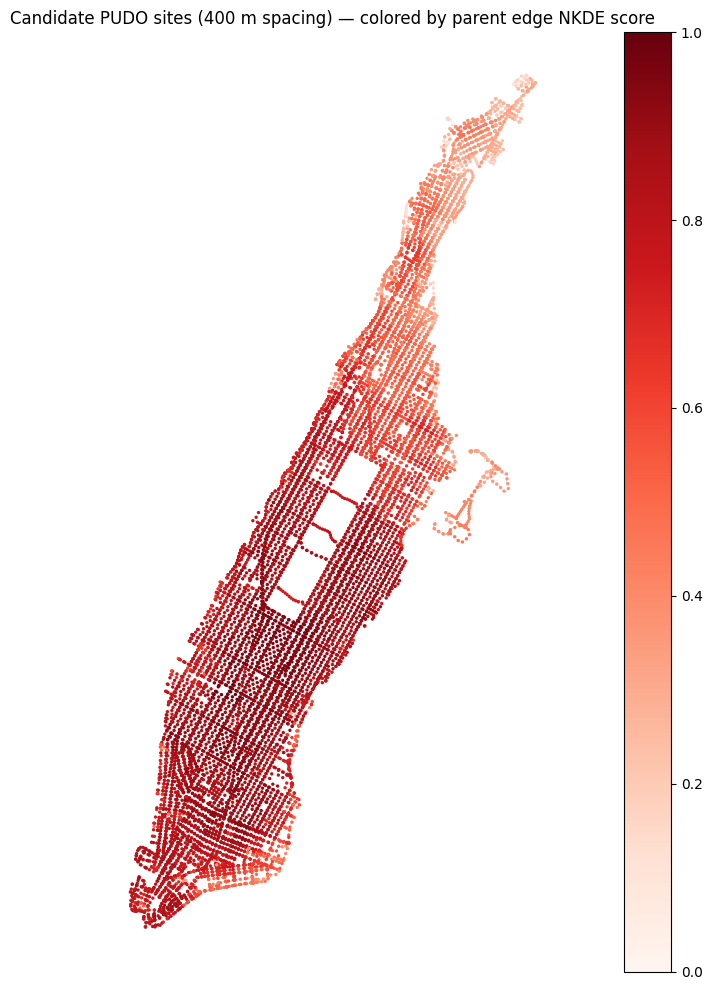

Map saved -> c:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\outputs\candidate_sites_map.png


In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_CRS = "EPSG:2263"
NKDE_PATH = PROJECT_ROOT / "data/processed/edges_with_nkde.gpkg"
CANDIDATES_PATH = PROJECT_ROOT / "data/processed/candidate_sites_raw.gpkg"
PLOT_PATH = PROJECT_ROOT / "data/outputs/candidate_sites_map.png"

EXCLUDED_HIGHWAYS = {
    "motorway",
    "motorway_link",
    "trunk",
    "trunk_link",
    "raceway",
    "service",
}
INTERVAL_M = 400.0


def _highway_values(highway) -> list[str]:
    if highway is None or (isinstance(highway, float) and np.isnan(highway)):
        return []
    if isinstance(highway, (list, tuple)):
        return [str(h) for h in highway]
    return [str(highway)]


def _highway_excluded(highway) -> bool:
    return bool(EXCLUDED_HIGHWAYS.intersection(_highway_values(highway)))


def _highway_type_label(highway) -> str:
    values = _highway_values(highway)
    return ", ".join(values) if values else ""


def _edge_id(u, v, key) -> str:
    return f"{u}_{v}_{key}"


def interpolate_candidates(geom, interval_m: float):
    length = geom.length
    if length <= 0:
        return []
    distances = np.arange(0, length, interval_m)
    return [geom.interpolate(float(d)) for d in distances]


# 1. Load edges with NKDE scores
edges = gpd.read_file(NKDE_PATH)
if edges.crs is None:
    edges = edges.set_crs(TARGET_CRS)
elif edges.crs.to_string() != TARGET_CRS:
    edges = edges.to_crs(TARGET_CRS)

print(f"Loaded {len(edges):,} edges from {NKDE_PATH.name} (CRS {edges.crs})")

# 2. Filter excluded highway types
exclude_mask = edges["highway"].apply(_highway_excluded)
n_removed = int(exclude_mask.sum())
edges_kept = edges.loc[~exclude_mask].copy()
print(f"Removed {n_removed:,} edges with excluded highway types")
print(f"Remaining edges: {len(edges_kept):,}")

# 3–5. Interpolate candidate points every 400 m along each edge
records = []
for row in edges_kept.itertuples(index=False):
    geom = row.geometry
    edge_id = _edge_id(row.u, row.v, row.key)
    highway_type = _highway_type_label(row.highway)
    nkde_score = row.nkde_score

    for pt in interpolate_candidates(geom, INTERVAL_M):
        records.append(
            {
                "geometry": pt,
                "nkde_score": nkde_score,
                "edge_id": edge_id,
                "highway_type": highway_type,
            }
        )

candidates = gpd.GeoDataFrame(records, geometry="geometry", crs=edges_kept.crs)

# 6. Summary
print(f"Total candidates generated: {len(candidates):,}")

# 7. Save
CANDIDATES_PATH.parent.mkdir(parents=True, exist_ok=True)
candidates.to_file(CANDIDATES_PATH, driver="GPKG")
print(f"Saved -> {CANDIDATES_PATH}")

# 8. Map: Manhattan road context + candidate points colored by NKDE
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(14, 10))

edges_kept.plot(
    ax=ax,
    color="#dddddd",
    linewidth=0.4,
    zorder=1,
)
candidates.plot(
    ax=ax,
    column="nkde_score",
    cmap="Reds",
    markersize=2,
    legend=True,
    zorder=2,
)

ax.set_title("Candidate PUDO sites (400 m spacing) — colored by parent edge NKDE score")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Map saved -> {PLOT_PATH}")


--- bus_stops ---
CRS: EPSG:2263
Shape: (756, 18)
Point    756
Name: count, dtype: int64

--- hydrants ---
CRS: EPSG:2263
Shape: (26204, 8)
Point    26204
Name: count, dtype: int64

--- bike_lanes ---
CRS: EPSG:2263
Shape: (13528, 25)
MultiLineString    13528
Name: count, dtype: int64

--- loading_zones ---
CRS: EPSG:2263
Shape: (11582, 23)
Point    11582
Name: count, dtype: int64


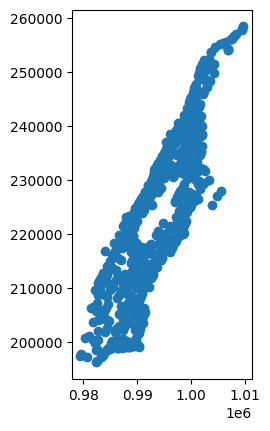

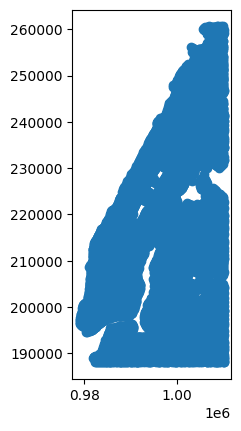

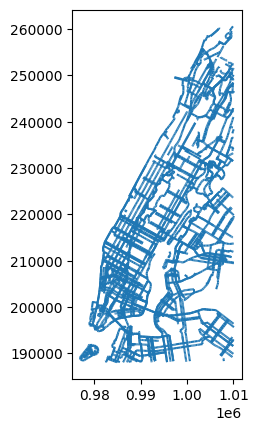

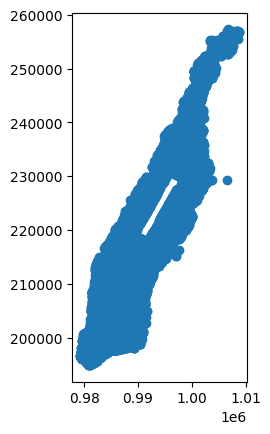

In [ ]:
import geopandas as gpd
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data/raw"
LAYER_FILES = {
    "bus_stops": "bus_stops.gpkg",
    "hydrants": "hydrants.gpkg",
    "bike_lanes": "bike_lanes.gpkg",
    "loading_zones": "loading_zones.gpkg",
}

missing = [name for name, fname in LAYER_FILES.items() if not (RAW_DIR / fname).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing NYC constraint layers in {RAW_DIR}: {', '.join(missing)}. "
        "Download them from the repo root: python src/download_nyc_layers.py"
    )

bus_stops = gpd.read_file(RAW_DIR / LAYER_FILES["bus_stops"])
hydrants = gpd.read_file(RAW_DIR / LAYER_FILES["hydrants"])
bike_lanes = gpd.read_file(RAW_DIR / LAYER_FILES["bike_lanes"])
loading_zones = gpd.read_file(RAW_DIR / LAYER_FILES["loading_zones"])

for name, layer in [("bus_stops", bus_stops), 
                     ("hydrants", hydrants),
                     ("bike_lanes", bike_lanes), 
                     ("loading_zones", loading_zones)]:
    print(f"\n--- {name} ---")
    print(f"CRS: {layer.crs}")
    print(f"Shape: {layer.shape}")
    print(layer.geometry.type.value_counts())
    layer.plot()

## Constraint filtering

Remove candidates that fall within exclusion distances of each NYC constraint layer:

| Layer | Buffer |
|---|---|
| Bus stop shelter | 15 m |
| Fire hydrant | 10 m |
| Bike lane | 5 m |
| Loading zone / no-standing sign | 10 m |

Starting candidates: 13,055

Applying filters:


C:\Users\Arv\AppData\Local\Temp\ipykernel_23384\4291833699.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffered_union = constraint.to_crs(TARGET_CRS).buffer(distance_m).unary_union


  Removed within 15 m of bus stop shelter: 0 → 13,055 remaining


C:\Users\Arv\AppData\Local\Temp\ipykernel_23384\4291833699.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffered_union = constraint.to_crs(TARGET_CRS).buffer(distance_m).unary_union


  Removed within 10 m of fire hydrant: 1 → 13,054 remaining


C:\Users\Arv\AppData\Local\Temp\ipykernel_23384\4291833699.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffered_union = constraint.to_crs(TARGET_CRS).buffer(distance_m).unary_union


  Removed within  5 m of bike lane: 4,958 → 8,096 remaining


C:\Users\Arv\AppData\Local\Temp\ipykernel_23384\4291833699.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffered_union = constraint.to_crs(TARGET_CRS).buffer(distance_m).unary_union


  Removed within 10 m of loading zone / no-standing sign: 452 → 7,644 remaining

Total remaining after all filters: 7,644
Saved → c:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\processed\candidate_sites_filtered.gpkg


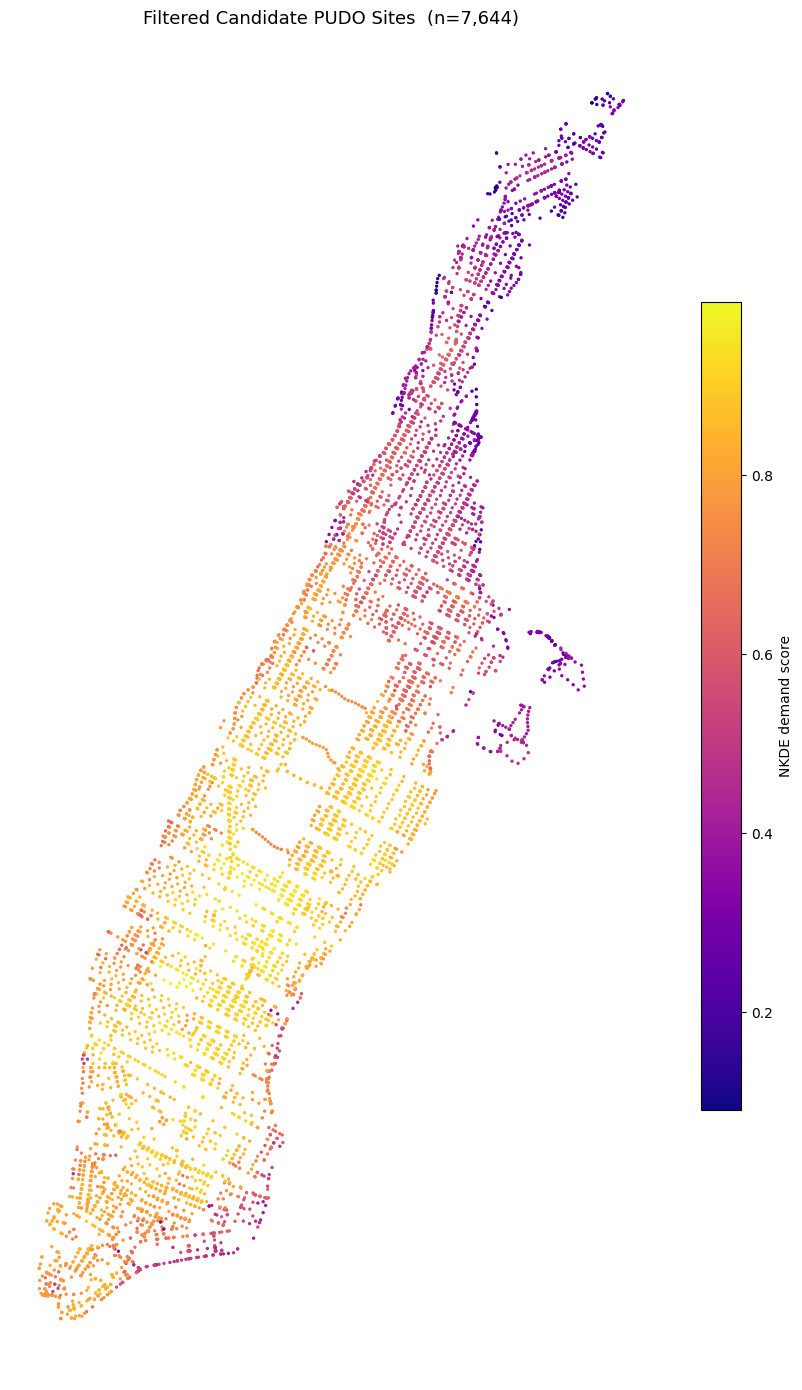

Plot saved → c:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\outputs\candidate_sites_filtered_map.png


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_CRS = "EPSG:2263"

# --- Load layers (re-use if already in memory) ---
if "candidates" not in globals():
    candidates = gpd.read_file(PROJECT_ROOT / "data/processed/candidate_sites_raw.gpkg")
if "bus_stops" not in globals():
    bus_stops = gpd.read_file(PROJECT_ROOT / "data/raw/bus_stops.gpkg")
if "hydrants" not in globals():
    hydrants = gpd.read_file(PROJECT_ROOT / "data/raw/hydrants.gpkg")
if "bike_lanes" not in globals():
    bike_lanes = gpd.read_file(PROJECT_ROOT / "data/raw/bike_lanes.gpkg")
if "loading_zones" not in globals():
    loading_zones = gpd.read_file(PROJECT_ROOT / "data/raw/loading_zones.gpkg")

print(f"Starting candidates: {len(candidates):,}")


def remove_within(candidates, constraint, distance_m, label):
    """Return candidates not within distance_m of any constraint geometry."""
    buffered_union = constraint.to_crs(TARGET_CRS).buffer(distance_m).unary_union
    mask = candidates.geometry.within(buffered_union)
    n_removed = int(mask.sum())
    kept = candidates[~mask].copy()
    print(f"  Removed within {distance_m:2d} m of {label}: {n_removed:,} → {len(kept):,} remaining")
    return kept


print("\nApplying filters:")
filtered = candidates.copy()
filtered = remove_within(filtered, bus_stops,    15, "bus stop shelter")
filtered = remove_within(filtered, hydrants,     10, "fire hydrant")
filtered = remove_within(filtered, bike_lanes,    5, "bike lane")
filtered = remove_within(filtered, loading_zones,10, "loading zone / no-standing sign")

print(f"\nTotal remaining after all filters: {len(filtered):,}")

# --- Save ---
out_path = PROJECT_ROOT / "data/processed/candidate_sites_filtered.gpkg"
filtered.to_file(out_path, driver="GPKG")
print(f"Saved → {out_path}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 14))
filtered.plot(
    ax=ax,
    column="nkde_score",
    cmap="plasma",
    markersize=2,
    legend=True,
    legend_kwds={"label": "NKDE demand score", "shrink": 0.6},
)
ax.set_title(f"Filtered Candidate PUDO Sites  (n={len(filtered):,})", fontsize=13)
ax.set_axis_off()
plt.tight_layout()

plot_path = PROJECT_ROOT / "data/outputs/candidate_sites_filtered_map.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved → {plot_path}")